In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

torch.manual_seed(42)
np.random.seed(42)

print("All imports done!")

All imports done!


In [10]:
le = LabelEncoder()

_tmp = pd.read_csv('Activity_Train.csv')
le.fit(_tmp['Activity'])
print("Classes:", list(le.classes_))

Classes: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


In [12]:
def load_data(train_path, val_path, test_path, target_col='Activity'):
    """
    Load csv files and convert to PyTorch tensors.
    Returns: (X_train, y_train, X_val, y_val, X_test, y_test)
    """
    train_df = pd.read_csv(train_path)
    val_df   = pd.read_csv(val_path)
    test_df  = pd.read_csv(test_path)

    X_train = torch.tensor(train_df.drop(columns=[target_col]).values, dtype=torch.float32)
    X_val   = torch.tensor(val_df.drop(columns=[target_col]).values,   dtype=torch.float32)
    X_test  = torch.tensor(test_df.drop(columns=[target_col]).values,  dtype=torch.float32)

    y_train = torch.tensor(le.transform(train_df[target_col]), dtype=torch.long)
    y_val   = torch.tensor(le.transform(val_df[target_col]),   dtype=torch.long)
    y_test  = torch.tensor(le.transform(test_df[target_col]),  dtype=torch.long)

    print(f"Train size: {X_train.shape}, Val size: {X_val.shape}, Test size: {X_test.shape}")
    print(f"Input features: {X_train.shape[1]}")
    return X_train, y_train, X_val, y_val, X_test, y_test


def train_model(model, X_train, y_train, lr=0.01, max_epochs=1000,
                patience=10, threshold=1e-3):
    """
    Train a model using SGD + CrossEntropy.
    Returns list of training losses per epoch.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    loss_history = []
    prev_loss = float('inf')
    counter   = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()

        outputs = model(X_train)
        loss    = criterion(outputs, y_train)

        loss.backward()
        optimizer.step()

        train_loss = loss.item()
        loss_history.append(train_loss)

        # convergence check
        if abs(train_loss - prev_loss) < threshold:
            counter += 1
        else:
            counter = 0
        prev_loss = train_loss

        if counter >= patience:
            print(f"  Converged at epoch {epoch} | Final loss: {train_loss:.4f}")
            break

        if epoch % 100 == 0:
            print(f"  Epoch {epoch}/{max_epochs} | Loss: {train_loss:.4f}")

    return loss_history


def evaluate_model(model, X, y):
    """
    Evaluate model, return accuracy and predictions.
    """
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        preds   = torch.argmax(outputs, dim=1)
    acc = accuracy_score(y.numpy(), preds.numpy())
    return acc, preds.numpy()


def print_metrics(y_true, y_pred, dataset_name="Test"):
    """
    Print confusion matrix + accuracy + micro/macro precision, recall, F1.
    """
    print(f"\n{'='*55}")
    print(f"  Metrics on {dataset_name} Data")
    print(f"{'='*55}")

    acc = accuracy_score(y_true, y_pred)
    print(f"  Accuracy: {acc*100:.2f}%")

    print("\n  Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    # plot confusion matrix nicely
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix - {dataset_name}')
    plt.tight_layout()
    plt.show()

    print("\n  Micro averages:")
    print(f"    Precision : {precision_score(y_true, y_pred, average='micro'):.4f}")
    print(f"    Recall    : {recall_score(y_true, y_pred, average='micro'):.4f}")
    print(f"    F1-score  : {f1_score(y_true, y_pred, average='micro'):.4f}")

    print("\n  Macro averages:")
    print(f"    Precision : {precision_score(y_true, y_pred, average='macro'):.4f}")
    print(f"    Recall    : {recall_score(y_true, y_pred, average='macro'):.4f}")
    print(f"    F1-score  : {f1_score(y_true, y_pred, average='macro'):.4f}")

    print("\n  Full Classification Report:")
    print(classification_report(y_true, y_pred, target_names=le.classes_))


def plot_loss_curves(loss_dict, title="Epoch vs Loss"):
    """
    Plot training loss curves for multiple architectures.
    loss_dict: {arch_label: [list of losses]}
    """
    plt.figure(figsize=(10, 5))
    for label, losses in loss_dict.items():
        plt.plot(losses, label=label)
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def save_models(models_dict, folder, prefix):
    """
    Save all models in a dictionary to a folder.
    models_dict: {label: model}
    """
    os.makedirs(folder, exist_ok=True)
    for label, model in models_dict.items():
        # make filename filesystem-safe
        safe_label = str(label).replace(' ', '_').replace('(', '').replace(')', '').replace(',', '_')
        path = os.path.join(folder, f"{prefix}_{safe_label}.pth")
        torch.save(model.state_dict(), path)
    print(f"  Saved {len(models_dict)} model(s) to '{folder}/'")


print("Helper functions defined!")

Helper functions defined!


In [13]:
class SingleHiddenLayerNN(nn.Module):
    """
    Neural network with ONE hidden layer.
    Architecture: Input -> Hidden (tanh) -> Output (softmax via CrossEntropyLoss)
    """
    def __init__(self, input_size, hidden_size, output_size=6):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),  # input layer (linear neurons)
            nn.Tanh(),                           # hidden layer activation
            nn.Linear(hidden_size, output_size)  # output layer (softmax applied by loss fn)
        )

    def forward(self, x):
        return self.layers(x)


class TwoHiddenLayerNN(nn.Module):
    """
    Neural network with TWO hidden layers.
    Architecture: Input -> Hidden1 (tanh) -> Hidden2 (tanh) -> Output
    """
    def __init__(self, input_size, h1, h2, output_size=6):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, h1),  # input to hidden layer 1
            nn.Tanh(),                  # activation for hidden layer 1
            nn.Linear(h1, h2),          # hidden layer 1 to hidden layer 2
            nn.Tanh(),                  # activation for hidden layer 2
            nn.Linear(h2, output_size)  # hidden layer 2 to output
        )

    def forward(self, x):
        return self.layers(x)


print("Model classes defined!")

Model classes defined!


In [16]:
print("Loading original dataset")
X_train_A, y_train_A, X_val_A, y_val_A, X_test_A, y_test_A = load_data(
    'Activity_Train.csv',
    'Activity_Validation.csv',
    'Activity_Test.csv'
)

INPUT_SIZE_A = X_train_A.shape[1] 
OUTPUT_SIZE  = 6
print(f"Input size: {INPUT_SIZE_A}, Output size: {OUTPUT_SIZE}")

Loading original dataset
Train size: torch.Size([6179, 561]), Val size: torch.Size([2060, 561]), Test size: torch.Size([2060, 561])
Input features: 561
Input size: 561, Output size: 6


In [17]:
# Architecture configurations for single hidden layer
single_archs_A = {
    'Arch1 (561)' : 561,
    'Arch2 (1024)': 1024,
    'Arch3 (128)' : 128,
}

single_models_A    = {}   # store trained models
single_losses_A    = {}   # store loss curves
single_val_accs_A  = {}   # store validation accuracies

for arch_name, hidden_size in single_archs_A.items():
    print(f"\nTraining Single Hidden Layer - {arch_name}")
    model = SingleHiddenLayerNN(INPUT_SIZE_A, hidden_size, OUTPUT_SIZE)
    losses = train_model(model, X_train_A, y_train_A,
                         lr=0.01, max_epochs=1000, patience=10, threshold=1e-3)
    val_acc, _ = evaluate_model(model, X_val_A, y_val_A)
    print(f"  Validation Accuracy: {val_acc*100:.2f}%")

    single_models_A[arch_name]   = model
    single_losses_A[arch_name]   = losses
    single_val_accs_A[arch_name] = val_acc

# save models
save_models(single_models_A, 'saved_models/partA', 'single')


Training Single Hidden Layer - Arch1 (561)
  Epoch 100/1000 | Loss: 0.9402
  Epoch 200/1000 | Loss: 0.7046
  Epoch 300/1000 | Loss: 0.5766
  Converged at epoch 309 | Final loss: 0.5678
  Validation Accuracy: 87.48%

Training Single Hidden Layer - Arch2 (1024)
  Epoch 100/1000 | Loss: 0.8752
  Epoch 200/1000 | Loss: 0.6465
  Converged at epoch 293 | Final loss: 0.5327
  Validation Accuracy: 88.83%

Training Single Hidden Layer - Arch3 (128)
  Epoch 100/1000 | Loss: 1.0819
  Epoch 200/1000 | Loss: 0.8294
  Epoch 300/1000 | Loss: 0.6864
  Converged at epoch 346 | Final loss: 0.6382
  Validation Accuracy: 87.62%
  Saved 3 model(s) to 'saved_models/partA/'


In [18]:
# Architecture configurations for two hidden layers
# (h1, h2)
two_archs_A = {
    'Arch1 (561,561)' : (561,  561),
    'Arch2 (1024,128)': (1024, 128),
    'Arch3 (1024,64)' : (1024,  64),
    'Arch4 (256,64)'  : (256,   64),
}

two_models_A    = {}
two_losses_A    = {}
two_val_accs_A  = {}

for arch_name, (h1, h2) in two_archs_A.items():
    print(f"\nTraining Two Hidden Layer - {arch_name}")
    model = TwoHiddenLayerNN(INPUT_SIZE_A, h1, h2, OUTPUT_SIZE)
    losses = train_model(model, X_train_A, y_train_A,
                         lr=0.01, max_epochs=1000, patience=10, threshold=1e-3)
    val_acc, _ = evaluate_model(model, X_val_A, y_val_A)
    print(f"  Validation Accuracy: {val_acc*100:.2f}%")

    two_models_A[arch_name]   = model
    two_losses_A[arch_name]   = losses
    two_val_accs_A[arch_name] = val_acc

# save models
save_models(two_models_A, 'saved_models/partA', 'two')


Training Two Hidden Layer - Arch1 (561,561)
  Epoch 100/1000 | Loss: 1.0983
  Epoch 200/1000 | Loss: 0.8230
  Epoch 300/1000 | Loss: 0.6613
  Converged at epoch 372 | Final loss: 0.5817
  Validation Accuracy: 86.02%

Training Two Hidden Layer - Arch2 (1024,128)
  Epoch 100/1000 | Loss: 1.1024
  Epoch 200/1000 | Loss: 0.8476
  Epoch 300/1000 | Loss: 0.6910
  Converged at epoch 386 | Final loss: 0.5955
  Validation Accuracy: 87.62%

Training Two Hidden Layer - Arch3 (1024,64)
  Epoch 100/1000 | Loss: 1.1699
  Epoch 200/1000 | Loss: 0.9130
  Epoch 300/1000 | Loss: 0.7507
  Converged at epoch 399 | Final loss: 0.6381
  Validation Accuracy: 86.75%

Training Two Hidden Layer - Arch4 (256,64)
  Epoch 100/1000 | Loss: 1.2682
  Epoch 200/1000 | Loss: 1.0217
  Epoch 300/1000 | Loss: 0.8648
  Epoch 400/1000 | Loss: 0.7438
  Converged at epoch 414 | Final loss: 0.7299
  Validation Accuracy: 82.86%
  Saved 4 model(s) to 'saved_models/partA/'


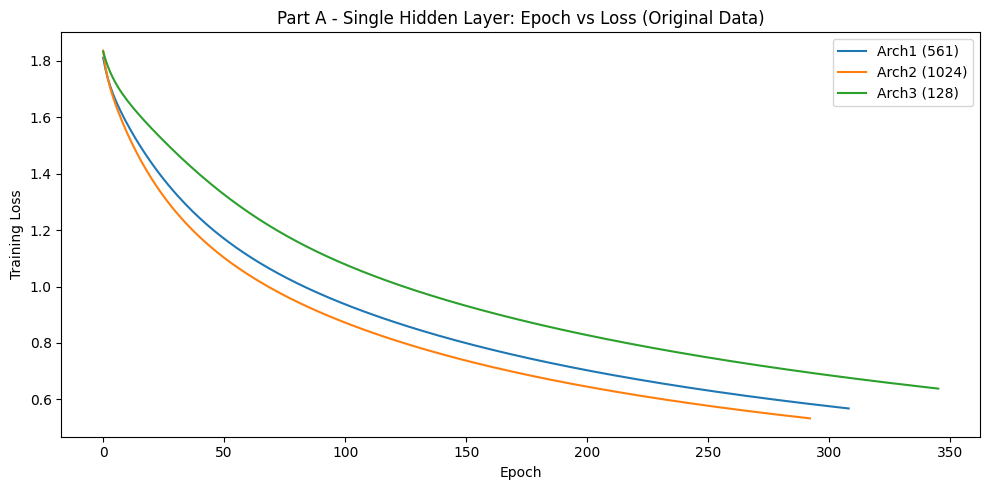

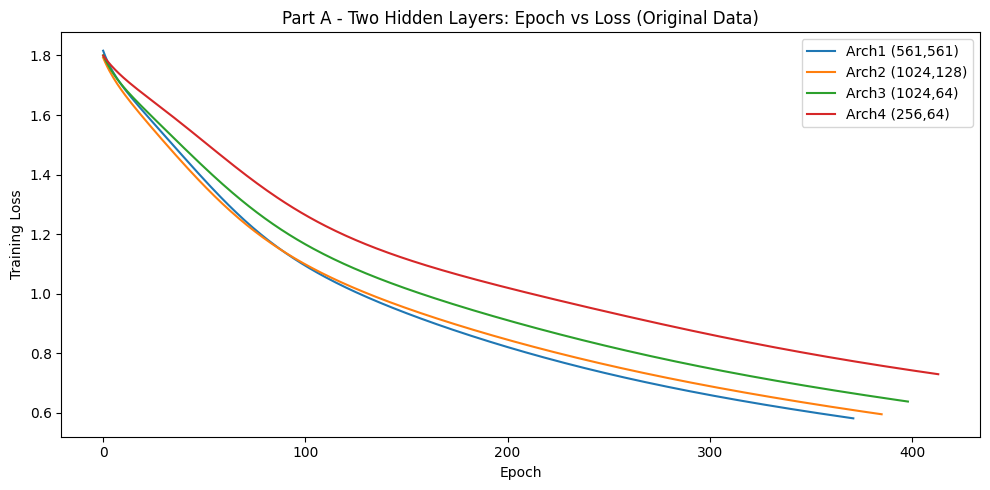

In [19]:
plot_loss_curves(single_losses_A, title="Part A - Single Hidden Layer: Epoch vs Loss (Original Data)")
plot_loss_curves(two_losses_A,    title="Part A - Two Hidden Layers: Epoch vs Loss (Original Data)")

In [20]:
print("--- Single Hidden Layer Validation Accuracies (Part A) ---")
for name, acc in single_val_accs_A.items():
    print(f"  {name}: {acc*100:.2f}%")

best_single_A = max(single_val_accs_A, key=single_val_accs_A.get)
print(f"\n  Best single hidden layer: {best_single_A} with val acc {single_val_accs_A[best_single_A]*100:.2f}%")

print("\n--- Two Hidden Layer Validation Accuracies (Part A) ---")
for name, acc in two_val_accs_A.items():
    print(f"  {name}: {acc*100:.2f}%")

best_two_A = max(two_val_accs_A, key=two_val_accs_A.get)
print(f"\n  Best two hidden layer: {best_two_A} with val acc {two_val_accs_A[best_two_A]*100:.2f}%")

--- Single Hidden Layer Validation Accuracies (Part A) ---
  Arch1 (561): 87.48%
  Arch2 (1024): 88.83%
  Arch3 (128): 87.62%

  Best single hidden layer: Arch2 (1024) with val acc 88.83%

--- Two Hidden Layer Validation Accuracies (Part A) ---
  Arch1 (561,561): 86.02%
  Arch2 (1024,128): 87.62%
  Arch3 (1024,64): 86.75%
  Arch4 (256,64): 82.86%

  Best two hidden layer: Arch2 (1024,128) with val acc 87.62%


Evaluating best single hidden layer model: Arch2 (1024)

  Metrics on Part A - Arch2 (1024) (Single Layer) Data
  Accuracy: 88.79%

  Confusion Matrix:
[[388   0   0   0   0   1]
 [  7 263  86   0   0   0]
 [  0  56 325   0   0   0]
 [  0   0   0 328   6  10]
 [  0   0   0  17 240  24]
 [  0   0   0  10  14 285]]


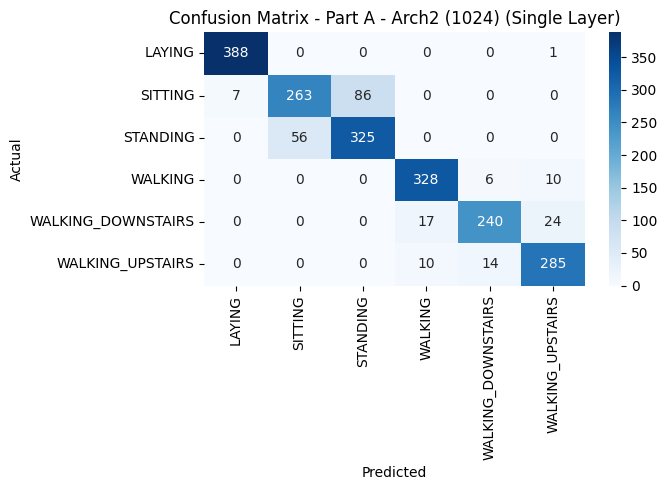


  Micro averages:
    Precision : 0.8879
    Recall    : 0.8879
    F1-score  : 0.8879

  Macro averages:
    Precision : 0.8892
    Recall    : 0.8865
    F1-score  : 0.8869

  Full Classification Report:
                    precision    recall  f1-score   support

            LAYING       0.98      1.00      0.99       389
           SITTING       0.82      0.74      0.78       356
          STANDING       0.79      0.85      0.82       381
           WALKING       0.92      0.95      0.94       344
WALKING_DOWNSTAIRS       0.92      0.85      0.89       281
  WALKING_UPSTAIRS       0.89      0.92      0.91       309

          accuracy                           0.89      2060
         macro avg       0.89      0.89      0.89      2060
      weighted avg       0.89      0.89      0.89      2060


Evaluating best two hidden layer model: Arch2 (1024,128)

  Metrics on Part A - Arch2 (1024,128) (Two Layers) Data
  Accuracy: 88.25%

  Confusion Matrix:
[[388   0   0   0   0   1]
 [  8 2

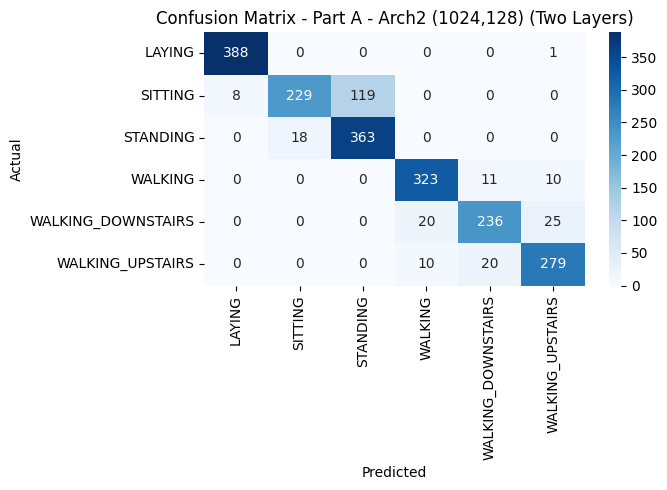


  Micro averages:
    Precision : 0.8825
    Recall    : 0.8825
    F1-score  : 0.8825

  Macro averages:
    Precision : 0.8908
    Recall    : 0.8792
    F1-score  : 0.8786

  Full Classification Report:
                    precision    recall  f1-score   support

            LAYING       0.98      1.00      0.99       389
           SITTING       0.93      0.64      0.76       356
          STANDING       0.75      0.95      0.84       381
           WALKING       0.92      0.94      0.93       344
WALKING_DOWNSTAIRS       0.88      0.84      0.86       281
  WALKING_UPSTAIRS       0.89      0.90      0.89       309

          accuracy                           0.88      2060
         macro avg       0.89      0.88      0.88      2060
      weighted avg       0.89      0.88      0.88      2060



In [21]:
print(f"Evaluating best single hidden layer model: {best_single_A}")
_, preds_single_A = evaluate_model(single_models_A[best_single_A], X_test_A, y_test_A)
print_metrics(y_test_A.numpy(), preds_single_A, dataset_name=f"Part A - {best_single_A} (Single Layer)")

print(f"\nEvaluating best two hidden layer model: {best_two_A}")
_, preds_two_A = evaluate_model(two_models_A[best_two_A], X_test_A, y_test_A)
print_metrics(y_test_A.numpy(), preds_two_A, dataset_name=f"Part A - {best_two_A} (Two Layers)")

In [22]:
# PART-B

print("Loading standardized dataset")
X_train_B, y_train_B, X_val_B, y_val_B, X_test_B, y_test_B = load_data(
    'Activity_Scaled_Train.csv',
    'Activity_Scaled_Validation.csv',
    'Activity_Scaled_Test.csv'
)

INPUT_SIZE_B = X_train_B.shape[1]  
print(f"Input size: {INPUT_SIZE_B}")

Loading standardized dataset
Train size: torch.Size([6179, 561]), Val size: torch.Size([2060, 561]), Test size: torch.Size([2060, 561])
Input features: 561
Input size: 561


In [47]:
single_archs_B = {
     'Arch1 (561)' : 561,
    'Arch2 (1024)': 1024,
    'Arch3 (128)' : 128,
}

single_models_B   = {}
single_losses_B   = {}
single_val_accs_B = {}

for arch_name, hidden_size in single_archs_B.items():
    print(f"\nTraining Single Hidden Layer - {arch_name}")
    model = SingleHiddenLayerNN(INPUT_SIZE_B, hidden_size, OUTPUT_SIZE)
    losses = train_model(model, X_train_B, y_train_B,
                         lr=0.01, max_epochs=1000, patience=10, threshold=1e-3)
    val_acc, _ = evaluate_model(model, X_val_B, y_val_B)
    print(f"  Validation Accuracy: {val_acc*100:.2f}%")

    single_models_B[arch_name]   = model
    single_losses_B[arch_name]   = losses
    single_val_accs_B[arch_name] = val_acc

save_models(single_models_B, 'saved_models/partB', 'single')


Training Single Hidden Layer - Arch1 (561)
  Epoch 100/1000 | Loss: 0.4954
  Epoch 200/1000 | Loss: 0.3386
  Converged at epoch 209 | Final loss: 0.3300
  Validation Accuracy: 91.21%

Training Single Hidden Layer - Arch2 (1024)
  Epoch 100/1000 | Loss: 0.4236
  Converged at epoch 182 | Final loss: 0.3105
  Validation Accuracy: 91.89%

Training Single Hidden Layer - Arch3 (128)
  Epoch 100/1000 | Loss: 0.6100
  Epoch 200/1000 | Loss: 0.4183
  Converged at epoch 246 | Final loss: 0.3684
  Validation Accuracy: 90.68%
  Saved 3 model(s) to 'saved_models/partB/'


In [48]:
two_archs_B = {
    'Arch1 (561,561)' : (561,  561),
    'Arch2 (1024,128)': (1024, 128),
    'Arch3 (1024,64)' : (1024,  64),
    'Arch4 (256,64)'  : (256,   64),
}

two_models_B   = {}
two_losses_B   = {}
two_val_accs_B = {}

for arch_name, (h1, h2) in two_archs_B.items():
    print(f"\nTraining Two Hidden Layer - {arch_name}")
    model = TwoHiddenLayerNN(INPUT_SIZE_B, h1, h2, OUTPUT_SIZE)
    losses = train_model(model, X_train_B, y_train_B,
                         lr=0.01, max_epochs=1000, patience=10, threshold=1e-3)
    val_acc, _ = evaluate_model(model, X_val_B, y_val_B)
    print(f"  Validation Accuracy: {val_acc*100:.2f}%")

    two_models_B[arch_name]   = model
    two_losses_B[arch_name]   = losses
    two_val_accs_B[arch_name] = val_acc

save_models(two_models_B, 'saved_models/partB', 'two')


Training Two Hidden Layer - Arch1 (561,561)
  Epoch 100/1000 | Loss: 0.6423
  Epoch 200/1000 | Loss: 0.4226
  Converged at epoch 268 | Final loss: 0.3436
  Validation Accuracy: 90.34%

Training Two Hidden Layer - Arch2 (1024,128)
  Epoch 100/1000 | Loss: 0.6765
  Epoch 200/1000 | Loss: 0.4488
  Converged at epoch 274 | Final loss: 0.3611
  Validation Accuracy: 90.53%

Training Two Hidden Layer - Arch3 (1024,64)
  Epoch 100/1000 | Loss: 0.7267
  Epoch 200/1000 | Loss: 0.4966
  Converged at epoch 285 | Final loss: 0.3945
  Validation Accuracy: 90.68%

Training Two Hidden Layer - Arch4 (256,64)
  Epoch 100/1000 | Loss: 0.8830
  Epoch 200/1000 | Loss: 0.6121
  Epoch 300/1000 | Loss: 0.4589
  Converged at epoch 342 | Final loss: 0.4147
  Validation Accuracy: 89.95%
  Saved 4 model(s) to 'saved_models/partB/'


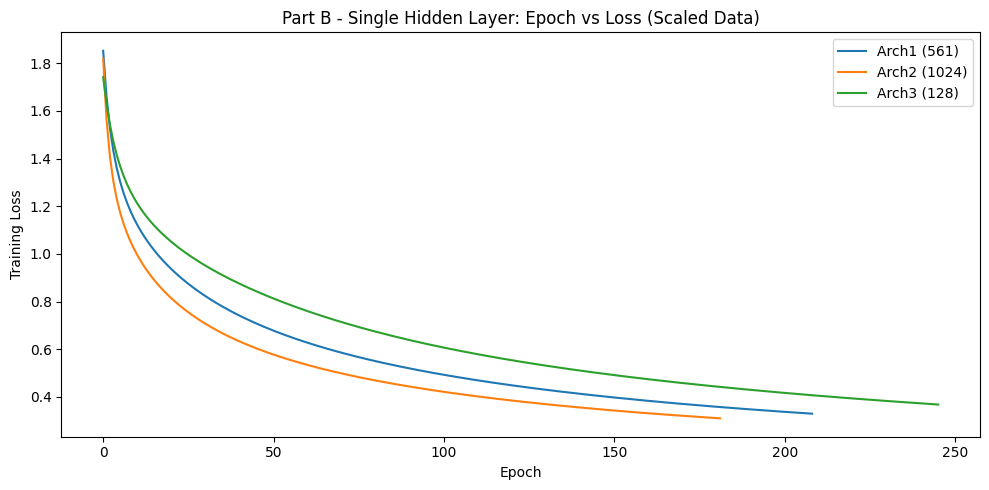

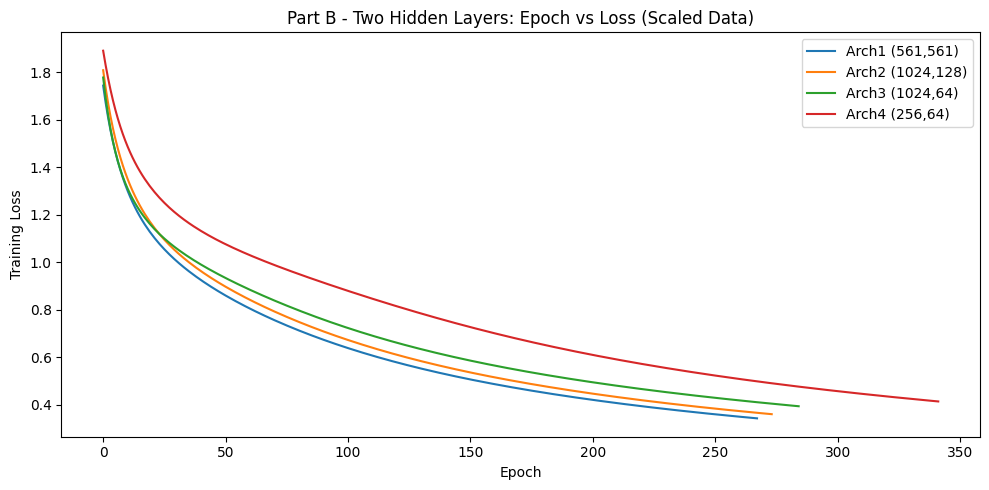

In [49]:
plot_loss_curves(single_losses_B, title="Part B - Single Hidden Layer: Epoch vs Loss (Scaled Data)")
plot_loss_curves(two_losses_B,    title="Part B - Two Hidden Layers: Epoch vs Loss (Scaled Data)")

In [50]:
print("--- Single Hidden Layer Validation Accuracies (Part B) ---")
for name, acc in single_val_accs_B.items():
    print(f"  {name}: {acc*100:.2f}%")
best_single_B = max(single_val_accs_B, key=single_val_accs_B.get)
print(f"\n  Best: {best_single_B} -> {single_val_accs_B[best_single_B]*100:.2f}%")

print("\n--- Two Hidden Layer Validation Accuracies (Part B) ---")
for name, acc in two_val_accs_B.items():
    print(f"  {name}: {acc*100:.2f}%")
best_two_B = max(two_val_accs_B, key=two_val_accs_B.get)
print(f"\n  Best: {best_two_B} -> {two_val_accs_B[best_two_B]*100:.2f}%")

--- Single Hidden Layer Validation Accuracies (Part B) ---
  Arch1 (561): 91.21%
  Arch2 (1024): 91.89%
  Arch3 (128): 90.68%

  Best: Arch2 (1024) -> 91.89%

--- Two Hidden Layer Validation Accuracies (Part B) ---
  Arch1 (561,561): 90.34%
  Arch2 (1024,128): 90.53%
  Arch3 (1024,64): 90.68%
  Arch4 (256,64): 89.95%

  Best: Arch3 (1024,64) -> 90.68%



  Metrics on Part B - Arch2 (1024) (Single Layer) Data
  Accuracy: 92.57%

  Confusion Matrix:
[[385   0   1   0   0   3]
 [  8 292  55   0   0   1]
 [  0  36 345   0   0   0]
 [  0   0   0 332   4   8]
 [  0   0   0   4 258  19]
 [  0   0   0   9   5 295]]


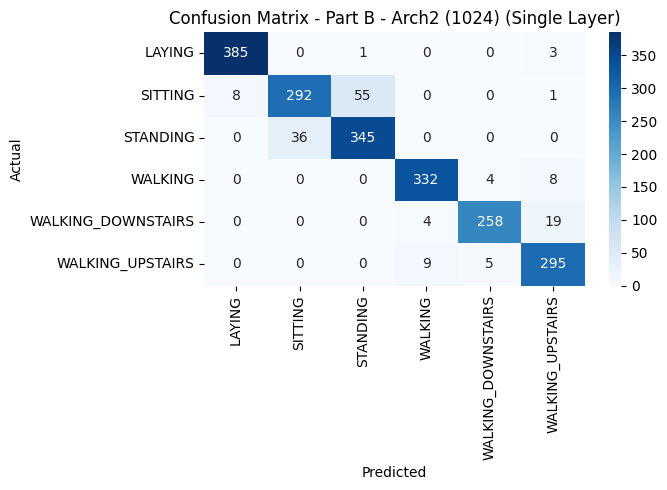


  Micro averages:
    Precision : 0.9257
    Recall    : 0.9257
    F1-score  : 0.9257

  Macro averages:
    Precision : 0.9273
    Recall    : 0.9256
    F1-score  : 0.9259

  Full Classification Report:
                    precision    recall  f1-score   support

            LAYING       0.98      0.99      0.98       389
           SITTING       0.89      0.82      0.85       356
          STANDING       0.86      0.91      0.88       381
           WALKING       0.96      0.97      0.96       344
WALKING_DOWNSTAIRS       0.97      0.92      0.94       281
  WALKING_UPSTAIRS       0.90      0.95      0.93       309

          accuracy                           0.93      2060
         macro avg       0.93      0.93      0.93      2060
      weighted avg       0.93      0.93      0.93      2060


  Metrics on Part B - Arch3 (1024,64) (Two Layers) Data
  Accuracy: 91.17%

  Confusion Matrix:
[[385   2   1   0   1   0]
 [ 12 259  85   0   0   0]
 [  0  21 360   0   0   0]
 [  0   0   

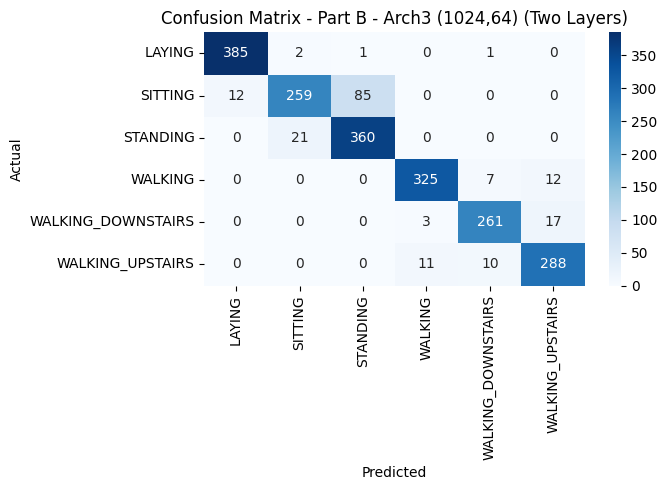


  Micro averages:
    Precision : 0.9117
    Recall    : 0.9117
    F1-score  : 0.9117

  Macro averages:
    Precision : 0.9163
    Recall    : 0.9113
    F1-score  : 0.9110

  Full Classification Report:
                    precision    recall  f1-score   support

            LAYING       0.97      0.99      0.98       389
           SITTING       0.92      0.73      0.81       356
          STANDING       0.81      0.94      0.87       381
           WALKING       0.96      0.94      0.95       344
WALKING_DOWNSTAIRS       0.94      0.93      0.93       281
  WALKING_UPSTAIRS       0.91      0.93      0.92       309

          accuracy                           0.91      2060
         macro avg       0.92      0.91      0.91      2060
      weighted avg       0.92      0.91      0.91      2060



In [51]:
_, preds_single_B = evaluate_model(single_models_B[best_single_B], X_test_B, y_test_B)
print_metrics(y_test_B.numpy(), preds_single_B, dataset_name=f"Part B - {best_single_B} (Single Layer)")

_, preds_two_B = evaluate_model(two_models_B[best_two_B], X_test_B, y_test_B)
print_metrics(y_test_B.numpy(), preds_two_B, dataset_name=f"Part B - {best_two_B} (Two Layers)")

In [52]:
print("Loading PCA-All dataset")
X_train_C, y_train_C, X_val_C, y_val_C, X_test_C, y_test_C = load_data(
    'Activity_PCAAll_Test.csv',
    'Activity_PCAAll_Validation.csv',
    'Activity_PCAAll_Test.csv'
)

INPUT_SIZE_C = X_train_C.shape[1]  
print(f"Input size: {INPUT_SIZE_C}")

Loading PCA-All dataset
Train size: torch.Size([2060, 561]), Val size: torch.Size([2060, 561]), Test size: torch.Size([2060, 561])
Input features: 561
Input size: 561


In [53]:
single_archs_C = {
    'Arch1 (561)' : 561,
    'Arch2 (1024)': 1024,
    'Arch3 (128)' : 128,
}

single_models_C   = {}
single_losses_C   = {}
single_val_accs_C = {}

for arch_name, hidden_size in single_archs_C.items():
    print(f"\nTraining Single Hidden Layer - {arch_name}")
    model = SingleHiddenLayerNN(INPUT_SIZE_C, hidden_size, OUTPUT_SIZE)
    losses = train_model(model, X_train_C, y_train_C,
                         lr=0.01, max_epochs=1000, patience=10, threshold=1e-3)
    val_acc, _ = evaluate_model(model, X_val_C, y_val_C)
    print(f"  Validation Accuracy: {val_acc*100:.2f}%")

    single_models_C[arch_name]   = model
    single_losses_C[arch_name]   = losses
    single_val_accs_C[arch_name] = val_acc

save_models(single_models_C, 'saved_models/partC', 'single')


Training Single Hidden Layer - Arch1 (561)
  Epoch 100/1000 | Loss: 0.9042
  Epoch 200/1000 | Loss: 0.6844
  Epoch 300/1000 | Loss: 0.5564
  Converged at epoch 315 | Final loss: 0.5416
  Validation Accuracy: 88.54%

Training Single Hidden Layer - Arch2 (1024)
  Epoch 100/1000 | Loss: 0.8034
  Epoch 200/1000 | Loss: 0.5996
  Converged at epoch 278 | Final loss: 0.5089
  Validation Accuracy: 88.25%

Training Single Hidden Layer - Arch3 (128)
  Epoch 100/1000 | Loss: 1.0137
  Epoch 200/1000 | Loss: 0.7942
  Epoch 300/1000 | Loss: 0.6566
  Converged at epoch 348 | Final loss: 0.6063
  Validation Accuracy: 87.09%
  Saved 3 model(s) to 'saved_models/partC/'


In [54]:
two_archs_C = {
    'Arch1 (561,561)' : (561,  561),
    'Arch2 (1024,128)': (1024, 128),
    'Arch3 (1024,64)' : (1024,  64),
    'Arch4 (256,64)'  : (256,   64),
}

two_models_C   = {}
two_losses_C   = {}
two_val_accs_C = {}

for arch_name, (h1, h2) in two_archs_C.items():
    print(f"\nTraining Two Hidden Layer - {arch_name}")
    model = TwoHiddenLayerNN(INPUT_SIZE_C, h1, h2, OUTPUT_SIZE)
    losses = train_model(model, X_train_C, y_train_C,
                         lr=0.01, max_epochs=1000, patience=10, threshold=1e-3)
    val_acc, _ = evaluate_model(model, X_val_C, y_val_C)
    print(f"  Validation Accuracy: {val_acc*100:.2f}%")

    two_models_C[arch_name]   = model
    two_losses_C[arch_name]   = losses
    two_val_accs_C[arch_name] = val_acc

save_models(two_models_C, 'saved_models/partC', 'two')


Training Two Hidden Layer - Arch1 (561,561)
  Epoch 100/1000 | Loss: 1.0206
  Epoch 200/1000 | Loss: 0.7924
  Epoch 300/1000 | Loss: 0.6403
  Converged at epoch 390 | Final loss: 0.5409
  Validation Accuracy: 87.09%

Training Two Hidden Layer - Arch2 (1024,128)
  Epoch 100/1000 | Loss: 1.0353
  Epoch 200/1000 | Loss: 0.8135
  Epoch 300/1000 | Loss: 0.6645
  Converged at epoch 392 | Final loss: 0.5636
  Validation Accuracy: 88.01%

Training Two Hidden Layer - Arch3 (1024,64)
  Epoch 100/1000 | Loss: 1.0605
  Epoch 200/1000 | Loss: 0.8495
  Epoch 300/1000 | Loss: 0.7046
  Converged at epoch 393 | Final loss: 0.6035
  Validation Accuracy: 87.48%

Training Two Hidden Layer - Arch4 (256,64)
  Epoch 100/1000 | Loss: 1.1649
  Epoch 200/1000 | Loss: 0.9899
  Epoch 300/1000 | Loss: 0.8470
  Epoch 400/1000 | Loss: 0.7232
  Converged at epoch 436 | Final loss: 0.6864
  Validation Accuracy: 84.47%
  Saved 4 model(s) to 'saved_models/partC/'


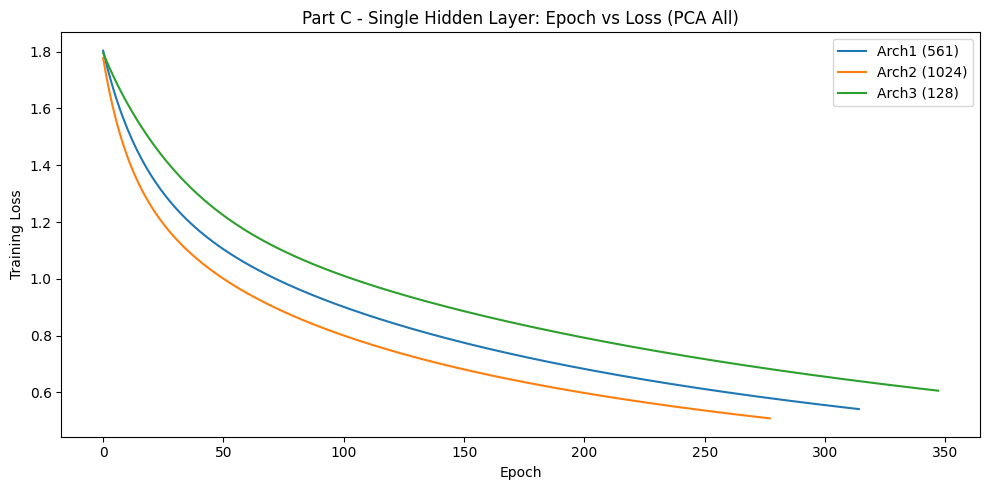

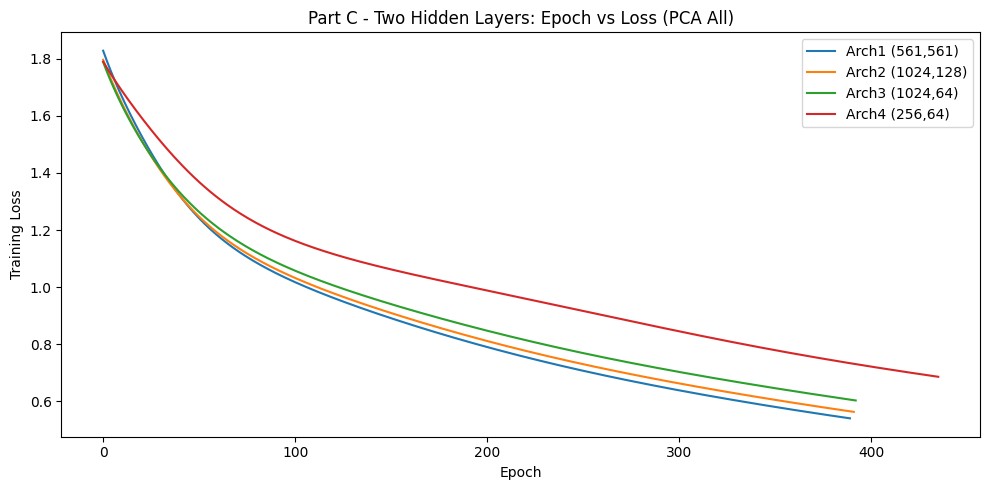

In [55]:
plot_loss_curves(single_losses_C, title="Part C - Single Hidden Layer: Epoch vs Loss (PCA All)")
plot_loss_curves(two_losses_C,    title="Part C - Two Hidden Layers: Epoch vs Loss (PCA All)")

In [56]:
print("--- Single Hidden Layer Validation Accuracies (Part C) ---")
for name, acc in single_val_accs_C.items():
    print(f"  {name}: {acc*100:.2f}%")
best_single_C = max(single_val_accs_C, key=single_val_accs_C.get)
print(f"\n  Best: {best_single_C} -> {single_val_accs_C[best_single_C]*100:.2f}%")

print("\n--- Two Hidden Layer Validation Accuracies (Part C) ---")
for name, acc in two_val_accs_C.items():
    print(f"  {name}: {acc*100:.2f}%")
best_two_C = max(two_val_accs_C, key=two_val_accs_C.get)
print(f"\n  Best: {best_two_C} -> {two_val_accs_C[best_two_C]*100:.2f}%")

--- Single Hidden Layer Validation Accuracies (Part C) ---
  Arch1 (561): 88.54%
  Arch2 (1024): 88.25%
  Arch3 (128): 87.09%

  Best: Arch1 (561) -> 88.54%

--- Two Hidden Layer Validation Accuracies (Part C) ---
  Arch1 (561,561): 87.09%
  Arch2 (1024,128): 88.01%
  Arch3 (1024,64): 87.48%
  Arch4 (256,64): 84.47%

  Best: Arch2 (1024,128) -> 88.01%



  Metrics on Part C - Arch1 (561) (Single Layer) Data
  Accuracy: 89.76%

  Confusion Matrix:
[[388   0   0   0   0   1]
 [  7 264  85   0   0   0]
 [  0  47 334   0   0   0]
 [  0   0   0 330   2  12]
 [  0   0   0   9 251  21]
 [  0   0   0   9  18 282]]


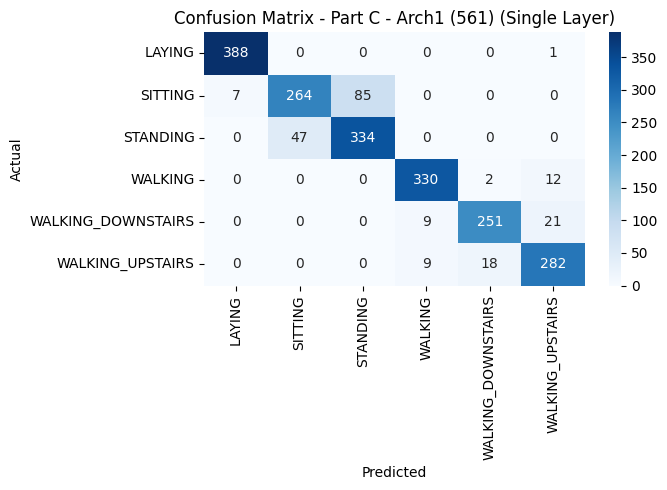


  Micro averages:
    Precision : 0.8976
    Recall    : 0.8976
    F1-score  : 0.8976

  Macro averages:
    Precision : 0.8992
    Recall    : 0.8968
    F1-score  : 0.8970

  Full Classification Report:
                    precision    recall  f1-score   support

            LAYING       0.98      1.00      0.99       389
           SITTING       0.85      0.74      0.79       356
          STANDING       0.80      0.88      0.83       381
           WALKING       0.95      0.96      0.95       344
WALKING_DOWNSTAIRS       0.93      0.89      0.91       281
  WALKING_UPSTAIRS       0.89      0.91      0.90       309

          accuracy                           0.90      2060
         macro avg       0.90      0.90      0.90      2060
      weighted avg       0.90      0.90      0.90      2060


  Metrics on Part C - Arch2 (1024,128) (Two Layers) Data
  Accuracy: 88.50%

  Confusion Matrix:
[[388   0   0   0   0   1]
 [ 10 225 121   0   0   0]
 [  0  28 353   0   0   0]
 [  0   0  

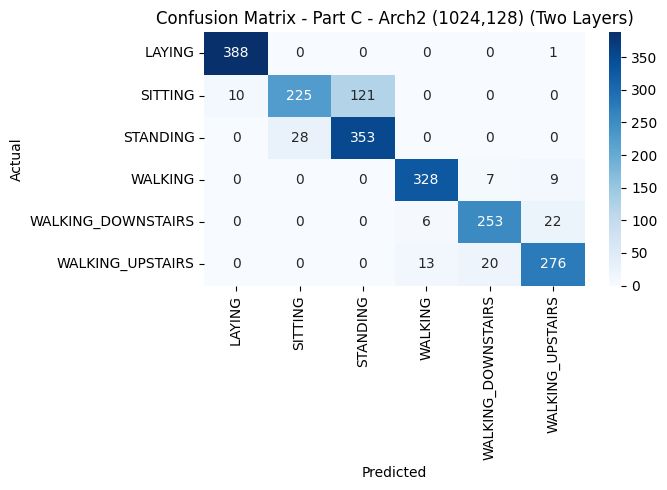


  Micro averages:
    Precision : 0.8850
    Recall    : 0.8850
    F1-score  : 0.8850

  Macro averages:
    Precision : 0.8923
    Recall    : 0.8838
    F1-score  : 0.8828

  Full Classification Report:
                    precision    recall  f1-score   support

            LAYING       0.97      1.00      0.99       389
           SITTING       0.89      0.63      0.74       356
          STANDING       0.74      0.93      0.83       381
           WALKING       0.95      0.95      0.95       344
WALKING_DOWNSTAIRS       0.90      0.90      0.90       281
  WALKING_UPSTAIRS       0.90      0.89      0.89       309

          accuracy                           0.88      2060
         macro avg       0.89      0.88      0.88      2060
      weighted avg       0.89      0.88      0.88      2060



In [57]:
_, preds_single_C = evaluate_model(single_models_C[best_single_C], X_test_C, y_test_C)
print_metrics(y_test_C.numpy(), preds_single_C, dataset_name=f"Part C - {best_single_C} (Single Layer)")

_, preds_two_C = evaluate_model(two_models_C[best_two_C], X_test_C, y_test_C)
print_metrics(y_test_C.numpy(), preds_two_C, dataset_name=f"Part C - {best_two_C} (Two Layers)")

In [58]:
print("Loading PCA-99 dataset...")
X_train_D, y_train_D, X_val_D, y_val_D, X_test_D, y_test_D = load_data(
    'Activity_PCA99_Train.csv',
    'Activity_PCA99_Validation.csv',
    'Activity_PCA99_Test.csv'
)

INPUT_SIZE_D = X_train_D.shape[1]  
print(f"Input size: {INPUT_SIZE_D}")

Loading PCA-99 dataset...
Train size: torch.Size([6179, 156]), Val size: torch.Size([2060, 156]), Test size: torch.Size([2060, 156])
Input features: 156
Input size: 156


In [59]:
single_archs_D = {
    'Arch1 (156)': 156,
    'Arch2 (512)': 512,
    'Arch3 (64)' : 64,
}

single_models_D   = {}
single_losses_D   = {}
single_val_accs_D = {}

for arch_name, hidden_size in single_archs_D.items():
    print(f"\nTraining Single Hidden Layer - {arch_name}")
    model = SingleHiddenLayerNN(INPUT_SIZE_D, hidden_size, OUTPUT_SIZE)
    losses = train_model(model, X_train_D, y_train_D,
                         lr=0.01, max_epochs=1000, patience=10, threshold=1e-3)
    val_acc, _ = evaluate_model(model, X_val_D, y_val_D)
    print(f"  Validation Accuracy: {val_acc*100:.2f}%")

    single_models_D[arch_name]   = model
    single_losses_D[arch_name]   = losses
    single_val_accs_D[arch_name] = val_acc

save_models(single_models_D, 'saved_models/partD', 'single')


Training Single Hidden Layer - Arch1 (156)
  Epoch 100/1000 | Loss: 0.9546
  Epoch 200/1000 | Loss: 0.7491
  Epoch 300/1000 | Loss: 0.6238
  Converged at epoch 316 | Final loss: 0.6079
  Validation Accuracy: 88.01%

Training Single Hidden Layer - Arch2 (512)
  Epoch 100/1000 | Loss: 0.7646
  Epoch 200/1000 | Loss: 0.5733
  Converged at epoch 256 | Final loss: 0.5113
  Validation Accuracy: 88.25%

Training Single Hidden Layer - Arch3 (64)
  Epoch 100/1000 | Loss: 1.0785
  Epoch 200/1000 | Loss: 0.8604
  Epoch 300/1000 | Loss: 0.7235
  Converged at epoch 351 | Final loss: 0.6699
  Validation Accuracy: 85.73%
  Saved 3 model(s) to 'saved_models/partD/'


In [60]:
two_archs_D = {
    'Arch1 (156,156)': (156, 156),
    'Arch2 (512,64)' : (512,  64),
    'Arch3 (256,64)' : (256,  64),
    'Arch4 (64,32)'  : (64,   32),
}

two_models_D   = {}
two_losses_D   = {}
two_val_accs_D = {}

for arch_name, (h1, h2) in two_archs_D.items():
    print(f"\nTraining Two Hidden Layer - {arch_name}")
    model = TwoHiddenLayerNN(INPUT_SIZE_D, h1, h2, OUTPUT_SIZE)
    losses = train_model(model, X_train_D, y_train_D,
                         lr=0.01, max_epochs=1000, patience=10, threshold=1e-3)
    val_acc, _ = evaluate_model(model, X_val_D, y_val_D)
    print(f"  Validation Accuracy: {val_acc*100:.2f}%")

    two_models_D[arch_name]   = model
    two_losses_D[arch_name]   = losses
    two_val_accs_D[arch_name] = val_acc

save_models(two_models_D, 'saved_models/partD', 'two')


Training Two Hidden Layer - Arch1 (156,156)
  Epoch 100/1000 | Loss: 1.0920
  Epoch 200/1000 | Loss: 0.8712
  Epoch 300/1000 | Loss: 0.7190
  Converged at epoch 387 | Final loss: 0.6225
  Validation Accuracy: 87.23%

Training Two Hidden Layer - Arch2 (512,64)
  Epoch 100/1000 | Loss: 1.0327
  Epoch 200/1000 | Loss: 0.8158
  Epoch 300/1000 | Loss: 0.6669
  Converged at epoch 383 | Final loss: 0.5758
  Validation Accuracy: 87.86%

Training Two Hidden Layer - Arch3 (256,64)
  Epoch 100/1000 | Loss: 1.1028
  Epoch 200/1000 | Loss: 0.9345
  Epoch 300/1000 | Loss: 0.7880
  Epoch 400/1000 | Loss: 0.6700
  Converged at epoch 423 | Final loss: 0.6469
  Validation Accuracy: 86.99%

Training Two Hidden Layer - Arch4 (64,32)
  Epoch 100/1000 | Loss: 1.3011
  Epoch 200/1000 | Loss: 1.1084
  Converged at epoch 232 | Final loss: 1.0754
  Validation Accuracy: 72.67%
  Saved 4 model(s) to 'saved_models/partD/'


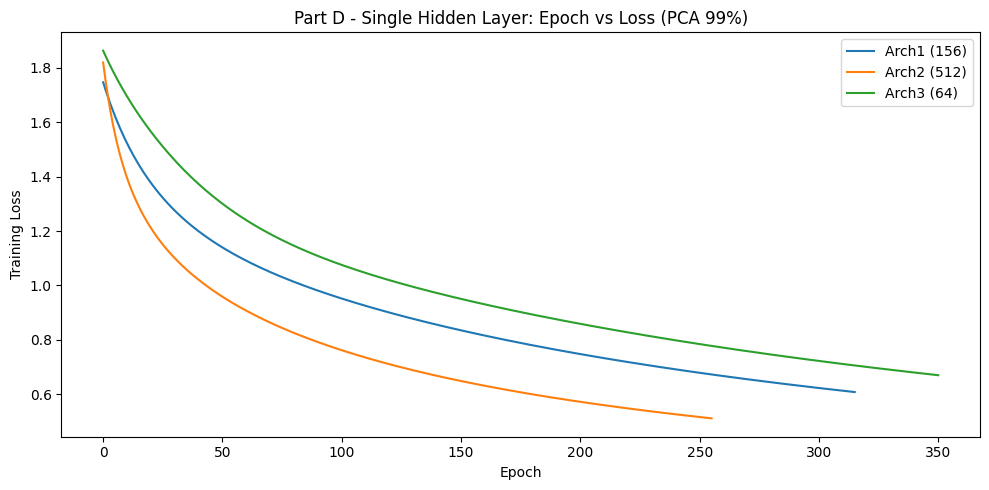

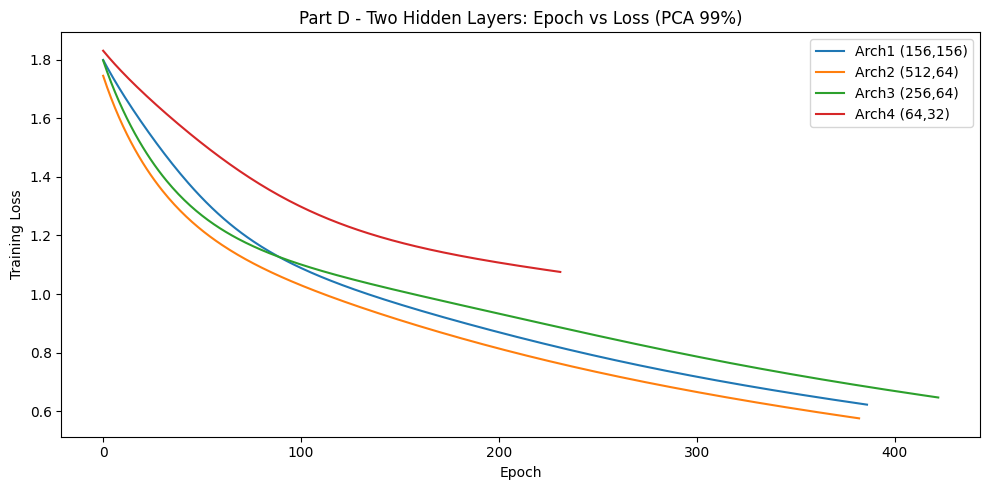

In [61]:
plot_loss_curves(single_losses_D, title="Part D - Single Hidden Layer: Epoch vs Loss (PCA 99%)")
plot_loss_curves(two_losses_D,    title="Part D - Two Hidden Layers: Epoch vs Loss (PCA 99%)")

In [62]:
print("--- Single Hidden Layer Validation Accuracies (Part D) ---")
for name, acc in single_val_accs_D.items():
    print(f"  {name}: {acc*100:.2f}%")
best_single_D = max(single_val_accs_D, key=single_val_accs_D.get)
print(f"\n  Best: {best_single_D} -> {single_val_accs_D[best_single_D]*100:.2f}%")

print("\n--- Two Hidden Layer Validation Accuracies (Part D) ---")
for name, acc in two_val_accs_D.items():
    print(f"  {name}: {acc*100:.2f}%")
best_two_D = max(two_val_accs_D, key=two_val_accs_D.get)
print(f"\n  Best: {best_two_D} -> {two_val_accs_D[best_two_D]*100:.2f}%")

--- Single Hidden Layer Validation Accuracies (Part D) ---
  Arch1 (156): 88.01%
  Arch2 (512): 88.25%
  Arch3 (64): 85.73%

  Best: Arch2 (512) -> 88.25%

--- Two Hidden Layer Validation Accuracies (Part D) ---
  Arch1 (156,156): 87.23%
  Arch2 (512,64): 87.86%
  Arch3 (256,64): 86.99%
  Arch4 (64,32): 72.67%

  Best: Arch2 (512,64) -> 87.86%



  Metrics on Part D - Arch2 (512) (Single Layer) Data
  Accuracy: 88.93%

  Confusion Matrix:
[[388   0   0   0   0   1]
 [  8 256  92   0   0   0]
 [  0  59 322   0   0   0]
 [  0   0   0 327   7  10]
 [  0   0   0   4 257  20]
 [  0   0   0   9  18 282]]


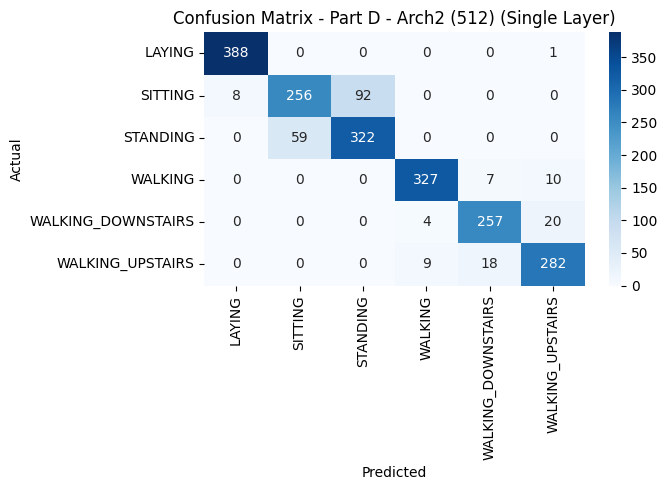


  Micro averages:
    Precision : 0.8893
    Recall    : 0.8893
    F1-score  : 0.8893

  Macro averages:
    Precision : 0.8907
    Recall    : 0.8899
    F1-score  : 0.8896

  Full Classification Report:
                    precision    recall  f1-score   support

            LAYING       0.98      1.00      0.99       389
           SITTING       0.81      0.72      0.76       356
          STANDING       0.78      0.85      0.81       381
           WALKING       0.96      0.95      0.96       344
WALKING_DOWNSTAIRS       0.91      0.91      0.91       281
  WALKING_UPSTAIRS       0.90      0.91      0.91       309

          accuracy                           0.89      2060
         macro avg       0.89      0.89      0.89      2060
      weighted avg       0.89      0.89      0.89      2060


  Metrics on Part D - Arch2 (512,64) (Two Layers) Data
  Accuracy: 88.59%

  Confusion Matrix:
[[388   0   0   0   0   1]
 [  9 244 103   0   0   0]
 [  0  40 341   0   0   0]
 [  0   0   0

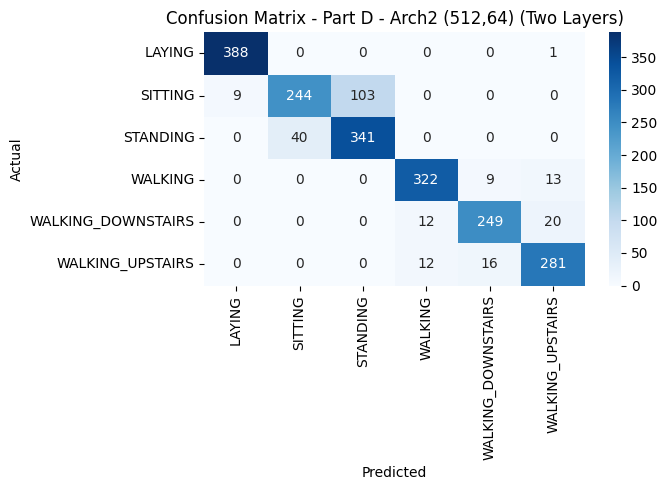


  Micro averages:
    Precision : 0.8859
    Recall    : 0.8859
    F1-score  : 0.8859

  Macro averages:
    Precision : 0.8893
    Recall    : 0.8849
    F1-score  : 0.8846

  Full Classification Report:
                    precision    recall  f1-score   support

            LAYING       0.98      1.00      0.99       389
           SITTING       0.86      0.69      0.76       356
          STANDING       0.77      0.90      0.83       381
           WALKING       0.93      0.94      0.93       344
WALKING_DOWNSTAIRS       0.91      0.89      0.90       281
  WALKING_UPSTAIRS       0.89      0.91      0.90       309

          accuracy                           0.89      2060
         macro avg       0.89      0.88      0.88      2060
      weighted avg       0.89      0.89      0.88      2060



In [63]:
_, preds_single_D = evaluate_model(single_models_D[best_single_D], X_test_D, y_test_D)
print_metrics(y_test_D.numpy(), preds_single_D, dataset_name=f"Part D - {best_single_D} (Single Layer)")

_, preds_two_D = evaluate_model(two_models_D[best_two_D], X_test_D, y_test_D)
print_metrics(y_test_D.numpy(), preds_two_D, dataset_name=f"Part D - {best_two_D} (Two Layers)")

In [65]:
# ---- collect test accuracies for each architecture ----

# Part A - single
acc_A_s1, _ = evaluate_model(single_models_A['Arch1 (561)'],  X_test_A, y_test_A)
acc_A_s2, _ = evaluate_model(single_models_A['Arch2 (1024)'], X_test_A, y_test_A)
acc_A_s3, _ = evaluate_model(single_models_A['Arch3 (128)'],  X_test_A, y_test_A)

# Part A - two
acc_A_t1, _ = evaluate_model(two_models_A['Arch1 (561,561)'],  X_test_A, y_test_A)
acc_A_t2, _ = evaluate_model(two_models_A['Arch2 (1024,128)'], X_test_A, y_test_A)
acc_A_t3, _ = evaluate_model(two_models_A['Arch3 (1024,64)'],  X_test_A, y_test_A)
acc_A_t4, _ = evaluate_model(two_models_A['Arch4 (256,64)'],   X_test_A, y_test_A)

# Part B - single
acc_B_s1, _ = evaluate_model(single_models_B['Arch1 (561)'],  X_test_B, y_test_B)
acc_B_s2, _ = evaluate_model(single_models_B['Arch2 (1024)'], X_test_B, y_test_B)
acc_B_s3, _ = evaluate_model(single_models_B['Arch3 (128)'],  X_test_B, y_test_B)

# Part B - two
acc_B_t1, _ = evaluate_model(two_models_B['Arch1 (561,561)'],   X_test_B, y_test_B)
acc_B_t2, _ = evaluate_model(two_models_B['Arch2 (1024,128)'],  X_test_B, y_test_B)
acc_B_t3, _ = evaluate_model(two_models_B['Arch3 (1024,64)'],  X_test_B, y_test_B)
acc_B_t4, _ = evaluate_model(two_models_B['Arch4 (256,64)'], X_test_B, y_test_B)

# Part C - single
acc_C_s1, _ = evaluate_model(single_models_C['Arch1 (561)'],  X_test_C, y_test_C)
acc_C_s2, _ = evaluate_model(single_models_C['Arch2 (1024)'], X_test_C, y_test_C)
acc_C_s3, _ = evaluate_model(single_models_C['Arch3 (128)'],  X_test_C, y_test_C)

# Part C - two
acc_C_t1, _ = evaluate_model(two_models_C['Arch1 (561,561)'],   X_test_C, y_test_C)
acc_C_t2, _ = evaluate_model(two_models_C['Arch2 (1024,128)'],  X_test_C, y_test_C)
acc_C_t3, _ = evaluate_model(two_models_C['Arch3 (1024,64)'],  X_test_C, y_test_C)
acc_C_t4, _ = evaluate_model(two_models_C['Arch4 (256,64)'], X_test_C, y_test_C)

# Part D - single
acc_D_s1, _ = evaluate_model(single_models_D['Arch1 (156)'], X_test_D, y_test_D)
acc_D_s2, _ = evaluate_model(single_models_D['Arch2 (512)'], X_test_D, y_test_D)
acc_D_s3, _ = evaluate_model(single_models_D['Arch3 (64)'],  X_test_D, y_test_D)

# Part D - two
acc_D_t1, _ = evaluate_model(two_models_D['Arch1 (156,156)'], X_test_D, y_test_D)
acc_D_t2, _ = evaluate_model(two_models_D['Arch2 (512,64)'],  X_test_D, y_test_D)
acc_D_t3, _ = evaluate_model(two_models_D['Arch3 (256,64)'],  X_test_D, y_test_D)
acc_D_t4, _ = evaluate_model(two_models_D['Arch4 (64,32)'],   X_test_D, y_test_D)

print("Test accuracies collected!")

Test accuracies collected!


In [66]:
#---- Build summary table ----


def pct(x):
    return round(x * 100, 2)

data = {
    "Dataset": ["Original", "Scaled", "PCA All", "PCA 99"],

    # single hidden layer models
    "Single Arch1 (%)": [pct(acc_A_s1), pct(acc_B_s1), pct(acc_C_s1), pct(acc_D_s1)],
    "Single Arch2 (%)": [pct(acc_A_s2), pct(acc_B_s2), pct(acc_C_s2), pct(acc_D_s2)],
    "Single Arch3 (%)": [pct(acc_A_s3), pct(acc_B_s3), pct(acc_C_s3), pct(acc_D_s3)],
    "Single Arch4 (%)": [None,          pct(acc_B_s4), pct(acc_C_s4), None         ],

    # two hidden layer models
    "Two Arch1 (%)": [pct(acc_A_t1), pct(acc_B_t1), pct(acc_C_t1), pct(acc_D_t1)],
    "Two Arch2 (%)": [pct(acc_A_t2), pct(acc_B_t2), pct(acc_C_t2), pct(acc_D_t2)],
    "Two Arch3 (%)": [pct(acc_A_t3), pct(acc_B_t3), pct(acc_C_t3), pct(acc_D_t3)],
    "Two Arch4 (%)": [pct(acc_A_t4), pct(acc_B_t4), pct(acc_C_t4), pct(acc_D_t4)],
}

df_summary = pd.DataFrame(data)
df_summary.set_index("Dataset", inplace=True)

print("\nTest Accuracy Comparison (%)")
print(df_summary.to_string())


Test Accuracy Comparison (%)
          Single Arch1 (%)  Single Arch2 (%)  Single Arch3 (%)  Single Arch4 (%)  Two Arch1 (%)  Two Arch2 (%)  Two Arch3 (%)  Two Arch4 (%)
Dataset                                                                                                                                     
Original             88.16             88.79             87.72               NaN          87.23          88.25          86.70          83.54
Scaled               92.18             92.57             91.46             91.94          92.23          91.89          91.17          90.87
PCA All              89.76             89.22             88.40             89.51          87.96          88.50          88.25          85.97
PCA 99               88.83             88.93             86.60               NaN          87.48          88.59          87.18          71.94


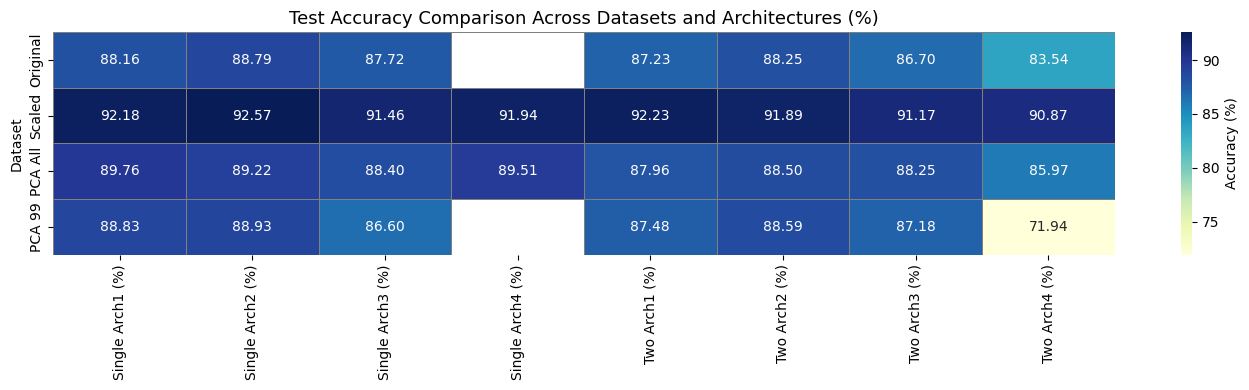

In [67]:
# ---- Visualize the summary table as a heatmap ----
plt.figure(figsize=(14, 4))
sns.heatmap(
    df_summary.astype(float),
    annot=True, fmt='.2f', cmap='YlGnBu',
    linewidths=0.5, linecolor='gray',
    cbar_kws={'label': 'Accuracy (%)'}
)
plt.title('Test Accuracy Comparison Across Datasets and Architectures (%)', fontsize=13)
plt.tight_layout()
plt.show()